# Estudo de Data Science: Previsão de Evasão em um Ambiente Virtual de Aprendizagem

Este notebook faz parte de um estudo acadêmico. O objetivo é transformar os registros de interação de estudantes com um AVA (Ambiente Virtual de Aprendizagem) em conhecimento: entender quais comportamentos levam à evasão e construir modelos capazes de prever, com antecedência, quem está em risco de abandonar o curso.

O dataset foi dividido em 4 arquivos de 5.000 registros cada, todos em formato CSV, somando 20.000 estudantes. Este notebook carrega os 4 arquivos, concatena e executa todo o fluxo: mineração, transformação, machine learning, gráficos, métricas e testes.

## Questões a serem resolvidas

1. Quais fatores de uso do AVA estão mais associados à evasão?
2. É possível prever, com base no comportamento de acesso, se um estudante está em risco de evasão?
3. Estudantes com acesso mais regular (menor regularity_index) evadem menos?
4. O desempenho médio em quizzes é um preditor relevante de evasão?

## Outras questões que também podem respondidas são:
5. Qual algoritmo de machine learning apresenta o melhor equilíbrio entre acurácia, recall e AUC-ROC?
6. Existe diferença estatisticamente significativa no tempo de acesso entre quem evadiu e quem permaneceu?
7. A disciplina em que o estudante está matriculado influencia a evasão?

In [1]:
# ============================================================
# Importação das bibliotecas
# ============================================================
import pandas as pd          # manipulação de dados tabulares
import numpy as np           # operações numéricas e arrays
import matplotlib.pyplot as plt  # criação de gráficos
import seaborn as sns        # gráficos estatísticos

# Modelos e ferramentas de machine learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve)

from scipy import stats      # testes estatísticos

import warnings
warnings.filterwarnings('ignore')  # evita poluir a saída com avisos

# Padronização visual dos gráficos
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

# Comentário sobre os comandos:
# Reunimos todas as dependências em uma única célula. O pandas e o numpy são a base
# da análise; matplotlib e seaborn geram os gráficos; o scikit-learn fornece os
# algoritmos e as métricas; o scipy fornece os testes estatísticos.

In [2]:
# ============================================================
# Carregamento dos 4 arquivos do dataset (todos CSV)
# ============================================================
# Os 4 arquivos estão em formato CSV. Ajuste os nomes abaixo
# conforme os arquivos que você baixou.

arquivo_parte1 = 'cap3_dataset_ava_parte1.csv'     # parte 1 (CSV)
arquivo_parte2 = 'cap3_dataset_ava_parte1.csv'     # parte 2 (CSV)
arquivo_parte3 = 'cap3_dataset_ava_parte1.csv'     # parte 3 (CSV)
arquivo_parte4 = 'cap3_dataset_ava_parte1.csv'     # parte 4 (CSV)

# Como todos os arquivos são CSV, usamos pd.read_csv para todos.
# O pandas detecta automaticamente o cabeçalho na primeira linha.
df_parte1 = pd.read_csv(arquivo_parte1)
df_parte2 = pd.read_csv(arquivo_parte2)
df_parte3 = pd.read_csv(arquivo_parte3)
df_parte4 = pd.read_csv(arquivo_parte4)

# Comentário sobre os comandos:
# Todos os arquivos estão no mesmo formato (CSV), então a mesma
# função de leitura é aplicada aos quatro. O read_csv lê arquivos
# de texto separados por vírgula e converte cada linha em um
# registro do DataFrame.

In [3]:
# ============================================================
# Concatenação das 4 partes em um único dataset
# ============================================================
# O pd.concat empilha os DataFrames verticalmente (axis=0), um abaixo do outro.
# O ignore_index=True renumera as linhas de 0 até o total, evitando índices repetidos.
df = pd.concat([df_parte1, df_parte2, df_parte3, df_parte4], axis=0, ignore_index=True)

print(f"Total de registros concatenados: {df.shape[0]}")
print(f"Total de colunas: {df.shape[1]}")

# Verificação de duplicatas de student_id: cada estudante deve aparecer uma única vez.
print(f"Duplicatas de student_id: {df['student_id'].duplicated().sum()}")
print(f"Faixa de student_id: {df['student_id'].min()} a {df['student_id'].max()}")

# Comentário sobre os comandos:
# A concatenação junta as 4 partes em um único DataFrame, permitindo analisar os
# 20.000 estudantes como um todo. A verificação de duplicatas garante que as partes
# não se sobrepõem, confirmando a integridade da divisão.

Total de registros concatenados: 20000
Total de colunas: 1


KeyError: 'student_id'

In [ ]:
#Erro acontecendo nessas linhas
# Verificação de duplicatas de student_id: cada estudante deve aparecer uma única vez.
#print(f"Duplicatas de student_id: {df['student_id'].duplicated().sum()}")
#print(f"Faixa de student_id: {df['student_id'].min()} a {df['student_id'].max()}")


print(df.head(3))

In [4]:
def ler_arquivo_dados(caminho):
    """Lê o arquivo tentando CSV (várias codificações e separadores) e Excel."""
    for enc in ['utf-8-sig', 'utf-8', 'latin-1', 'cp1252']:
        for sep in [',', ';', '\t']:
            try:
                df_tmp = pd.read_csv(caminho, encoding=enc, sep=sep)
                if 'student_id' in df_tmp.columns:
                    return df_tmp
            except (UnicodeDecodeError, UnicodeError, pd.errors.ParserError):
                continue
    try:
        return pd.read_excel(caminho)
    except Exception:
        raise ValueError(f"Não foi possível ler o arquivo {caminho}")


In [6]:
df_parte1 = ler_arquivo_dados('cap3_dataset_ava_parte1.csv')
df_parte2 = ler_arquivo_dados('cap3_dataset_ava_parte2.csv')
df_parte3 = ler_arquivo_dados('cap3_dataset_ava_parte3.csv')
df_parte4 = ler_arquivo_dados('cap3_dataset_ava_parte4.csv')

# Normalização preventiva: remove espaços extras nos nomes das colunas
for df_parte in [df_parte1, df_parte2, df_parte3, df_parte4]:
    df_parte.columns = df_parte.columns.str.strip()

# Concatenação e confirmação
df = pd.concat([df_parte1, df_parte2, df_parte3, df_parte4], axis=0, ignore_index=True)
print("Colunas:", list(df.columns))
print("Registros:", df.shape[0])

Colunas: ['student_id', 'course', 'total_accesses', 'total_time_minutes', 'avg_time_per_access', 'days_active', 'modules_accessed', 'activities_completed', 'quizzes_taken', 'avg_quiz_score', 'forum_posts', 'forum_reads', 'videos_watched', 'assignments_submitted', 'weekend_access_ratio', 'regularity_index', 'dropout']
Registros: 20000


In [7]:
# ============================================================
# Dicionário de dados
# ============================================================
# Cria um DataFrame com a descrição de cada coluna, para consulta rápida no estudo.
dicionario = pd.DataFrame({
    'Coluna': ['student_id', 'course', 'total_accesses', 'total_time_minutes',
               'avg_time_per_access', 'days_active', 'modules_accessed',
               'activities_completed', 'quizzes_taken', 'avg_quiz_score',
               'forum_posts', 'forum_reads', 'videos_watched',
               'assignments_submitted', 'weekend_access_ratio',
               'regularity_index', 'dropout'],
    'Tipo': ['int64', 'object', 'int64', 'int64', 'float64', 'int64', 'int64',
             'int64', 'int64', 'float64', 'int64', 'int64', 'int64', 'int64',
             'float64', 'float64', 'int64'],
    'Descricao': ['Identificador único do estudante',
                  'Disciplina do curso',
                  'Número total de acessos ao AVA',
                  'Tempo total de permanência em minutos',
                  'Tempo médio por acesso em minutos',
                  'Dias distintos com pelo menos um acesso',
                  'Módulos do curso acessados',
                  'Atividades concluídas',
                  'Quizzes realizados',
                  'Nota média nos quizzes (0 a 10)',
                  'Mensagens publicadas em fóruns',
                  'Leituras de mensagens em fóruns',
                  'Vídeos assistidos',
                  'Trabalhos entregues',
                  'Proporção de acessos no fim de semana',
                  'Coeficiente de variação dos acessos semanais',
                  'Variável alvo: 1 = evadiu, 0 = permaneceu'],
    'Observacoes': ['Sem duplicatas entre as partes', 'Categórica, exige codificação',
                    '', 'Contém ~1% de outliers', 'Tempo total ÷ acessos', '',
                    '', '', '', 'NaN quando nenhum quiz foi feito', 'NaN em ~2%',
                    '', '', '', '', 'Menor = mais regular', 'Alvo da classificação']
})

dicionario

# Comentário sobre os comandos:
# O dicionário de dados documenta o significado de cada coluna, o tipo e as
# particularidades (valores ausentes, outliers). É a referência conceitual que
# orienta todas as decisões de tratamento e modelagem.

,Coluna,Tipo,Descricao,Observacoes
0,student_id,int64,Identificador único do estudante,Sem duplicatas entre as partes
1,course,object,Disciplina do curso,"Categórica, exige codificação"
2,total_accesses,int64,Número total de acessos ao AVA,
3,total_time_minutes,int64,Tempo total de permanência em minutos,Contém ~1% de outliers
4,avg_time_per_access,float64,Tempo médio por acesso em minutos,Tempo total ÷ acessos
5,days_active,int64,Dias distintos com pelo menos um acesso,
6,modules_accessed,int64,Módulos do curso acessados,
7,activities_completed,int64,Atividades concluídas,
8,quizzes_taken,int64,Quizzes realizados,
9,avg_quiz_score,float64,Nota média nos quizzes (0 a 10),NaN quando nenhum quiz foi feito


In [8]:
# ============================================================
# Tipos de dados e valores não nulos
# ============================================================
df.info()

# Comentário sobre os comandos:
# O info() mostra o tipo de cada coluna e quantos valores não nulos existem.
# Colunas com contagem menor que 20.000 indicam a presença de dados ausentes,
# como avg_quiz_score e forum_posts.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   course                 20000 non-null  object 
 2   total_accesses         20000 non-null  int64  
 3   total_time_minutes     20000 non-null  int64  
 4   avg_time_per_access    20000 non-null  float64
 5   days_active            20000 non-null  int64  
 6   modules_accessed       20000 non-null  int64  
 7   activities_completed   20000 non-null  int64  
 8   quizzes_taken          20000 non-null  int64  
 9   avg_quiz_score         18252 non-null  float64
 10  forum_posts            19599 non-null  float64
 11  forum_reads            20000 non-null  int64  
 12  videos_watched         20000 non-null  int64  
 13  assignments_submitted  20000 non-null  int64  
 14  weekend_access_ratio   20000 non-null  float64
 15  re

In [9]:
# ============================================================
# Estatísticas descritivas
# ============================================================
df.describe().T

# Comentário sobre os comandos:
# O describe() calcula média, desvio padrão, mínimo, quartis e máximo de cada
# coluna numérica. Compare o máximo de total_time_minutes com o terceiro quartil:
# se houver grande diferença, há indício de outliers.

,count,mean,std,min,25%,50%,75%,max
student_id,20000.0,20000.500000,5773.647028,10001.0,15000.7500,20000.50,25000.25,30000.0
total_accesses,20000.0,45.037100,19.901300,0.0,31.0000,45.00,59.00,133.0
total_time_minutes,20000.0,931.421350,500.626030,0.0,636.0000,908.00,1180.00,8401.0
avg_time_per_access,20000.0,30.159421,66.888713,0.0,12.6075,19.89,30.70,4428.0
days_active,20000.0,60.857900,34.716278,1.0,31.0000,61.00,91.00,120.0
modules_accessed,20000.0,5.507600,2.866907,1.0,3.0000,6.00,8.00,10.0
activities_completed,20000.0,15.112150,8.914502,0.0,7.0000,15.00,23.00,30.0
quizzes_taken,20000.0,5.817950,3.823812,0.0,2.0000,6.00,9.00,12.0
avg_quiz_score,18252.0,4.984580,2.879285,0.0,2.5300,4.96,7.47,10.0
forum_posts,19599.0,3.000969,1.737037,0.0,2.0000,3.00,4.00,13.0


In [10]:
# ============================================================
# Diagnóstico de valores ausentes
# ============================================================
ausentes = df.isnull().sum()
percentual = (df.isnull().sum() / len(df)) * 100
pd.DataFrame({'Valores ausentes': ausentes, 'Percentual (%)': percentual.round(2)})

# Comentário sobre os comandos:
# Antes de modelar, precisamos saber onde estão os dados ausentes, pois a maioria
# dos algoritmos de machine learning não os aceita. O tratamento é obrigatório.

,Valores ausentes,Percentual (%)
student_id,0,0.00
course,0,0.00
total_accesses,0,0.00
total_time_minutes,0,0.00
avg_time_per_access,0,0.00
days_active,0,0.00
modules_accessed,0,0.00
activities_completed,0,0.00
quizzes_taken,0,0.00
avg_quiz_score,1748,8.74


In [11]:
# ============================================================
# Verificação de duplicatas
# ============================================================
print(f"Linhas duplicadas: {df.duplicated().sum()}")

# Comentário sobre os comandos:
# Duplicatas podem inflar padrões e viciar o modelo. Como cada linha é um
# estudante único, qualquer duplicata seria um erro de extração a remover.

Linhas duplicadas: 0


dropout
0    77.44
1    22.56
Name: proportion, dtype: float64


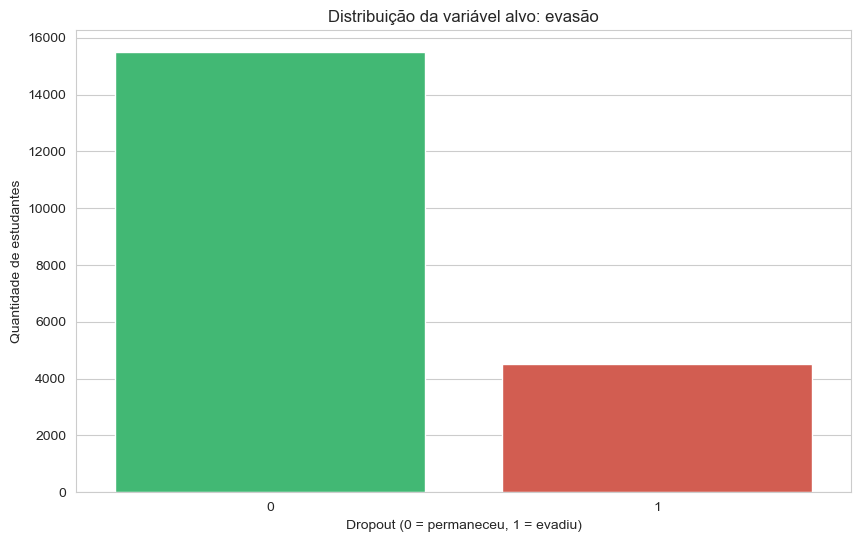

In [12]:
# ============================================================
# Distribuição da variável alvo (dropout)
# ============================================================
print(df['dropout'].value_counts(normalize=True).round(4) * 100)

sns.countplot(x='dropout', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Distribuição da variável alvo: evasão')
plt.xlabel('Dropout (0 = permaneceu, 1 = evadiu)')
plt.ylabel('Quantidade de estudantes')
plt.show()

# Comentário sobre os comandos:
# A variável alvo é o coração do problema. A proporção de evasão indica se o
# problema é relevante e se há desbalanceamento, o que justifica o uso de
# estratificação na divisão treino/teste.

In [13]:
# ============================================================
# Imputação de valores ausentes com a mediana
# ============================================================
# A mediana é robusta a outliers, diferente da média.
for coluna in ['avg_quiz_score', 'forum_posts']:
    mediana = df[coluna].median()
    df[coluna] = df[coluna].fillna(mediana)
    print(f"{coluna}: preenchidos com a mediana {mediana:.2f}")

print("\nValores ausentes restantes:", df.isnull().sum().sum())

# Comentário sobre os comandos:
# Existem três estratégias para valores ausentes: remover linhas, remover colunas
# ou preencher (imputar). Remover 12% das linhas desperdiçaria dados valiosos.
# A imputação pela mediana é a escolha mais segura, pois não é influenciada por
# outliers. Para avg_quiz_score, a mediana representa a nota típica, uma
# estimativa razoável para quem não fez quizzes.

avg_quiz_score: preenchidos com a mediana 4.96
forum_posts: preenchidos com a mediana 3.00

Valores ausentes restantes: 0


In [14]:
# ============================================================
# Tratamento de outliers (winsorização via IQR)
# ============================================================
def tratar_outliers(df, coluna):
    """Limita valores extremos com base no intervalo interquartil (IQR)."""
    Q1 = df[coluna].quantile(0.25)          # primeiro quartil
    Q3 = df[coluna].quantile(0.75)          # terceiro quartil
    IQR = Q3 - Q1                           # intervalo interquartil
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    # clip() "cap" os valores nos limites, em vez de descartar as linhas
    df[coluna] = df[coluna].clip(lower=limite_inferior, upper=limite_superior)
    return df

for coluna in ['total_time_minutes', 'total_accesses', 'avg_time_per_access']:
    antes = df[coluna].max()
    df = tratar_outliers(df, coluna)
    print(f"{coluna}: máximo antes = {antes:.0f}, depois = {df[coluna].max():.0f}")

# Comentário sobre os comandos:
# Outliers extremos podem distorcer a média, o escalonamento e o treinamento dos
# modelos. A regra do IQR considera outliers os valores abaixo de Q1 - 1.5*IQR ou
# acima de Q3 + 1.5*IQR. Em vez de descartar as linhas, aplicamos a winsorização:
# os valores extremos são limitados nos limites calculados, preservando o registro
# mas neutralizando o efeito do valor extremo.

total_time_minutes: máximo antes = 8401, depois = 1996
total_accesses: máximo antes = 133, depois = 101
avg_time_per_access: máximo antes = 4428, depois = 58


In [15]:
# ============================================================
# Codificação da variável categórica (course)
# ============================================================
encoder = LabelEncoder()
df['course_encoded'] = encoder.fit_transform(df['course'])

# Mapeamento para consulta
mapeamento = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("Codificação das disciplinas:", mapeamento)

# Comentário sobre os comandos:
# Algoritmos de machine learning trabalham apenas com números. A coluna course é
# textual, então precisamos convertê-la. O LabelEncoder atribui um número inteiro
# a cada disciplina. Para variáveis nominais sem ordem natural, o One-Hot Encoding
# seria mais indicado (ver Parte Avançada); aqui usamos o LabelEncoder por
# simplicidade didática.

Codificação das disciplinas: {'Banco de Dados': np.int64(0), 'Estatística': np.int64(1), 'Matemática Discreta': np.int64(2), 'Programação I': np.int64(3), 'Redes de Computadores': np.int64(4)}


In [16]:
# ============================================================
# Engenharia de atributos (índice de engajamento)
# ============================================================
# Combina indicadores de engajamento em um único score normalizado (0 a 1)
df['engagement_index'] = (
    (df['total_accesses'] / df['total_accesses'].max()) * 0.3 +
    (df['days_active'] / df['days_active'].max()) * 0.3 +
    (df['activities_completed'] / df['activities_completed'].max()) * 0.2 +
    (df['avg_quiz_score'] / 10) * 0.2
)

print(f"Engagement index: média = {df['engagement_index'].mean():.3f}, "
      f"desvio = {df['engagement_index'].std():.3f}")

# Comentário sobre os comandos:
# A engenharia de atributos cria novas variáveis a partir das existentes,
# capturando conceitos que nenhuma coluna isolada representa. O engagement_index
# sintetiza quatro indicadores de engajamento em um único score entre 0 e 1.
# Cada componente é normalizado pela sua escala máxima e ponderado por sua
# importância presumida.

Engagement index: média = 0.486, desvio = 0.132


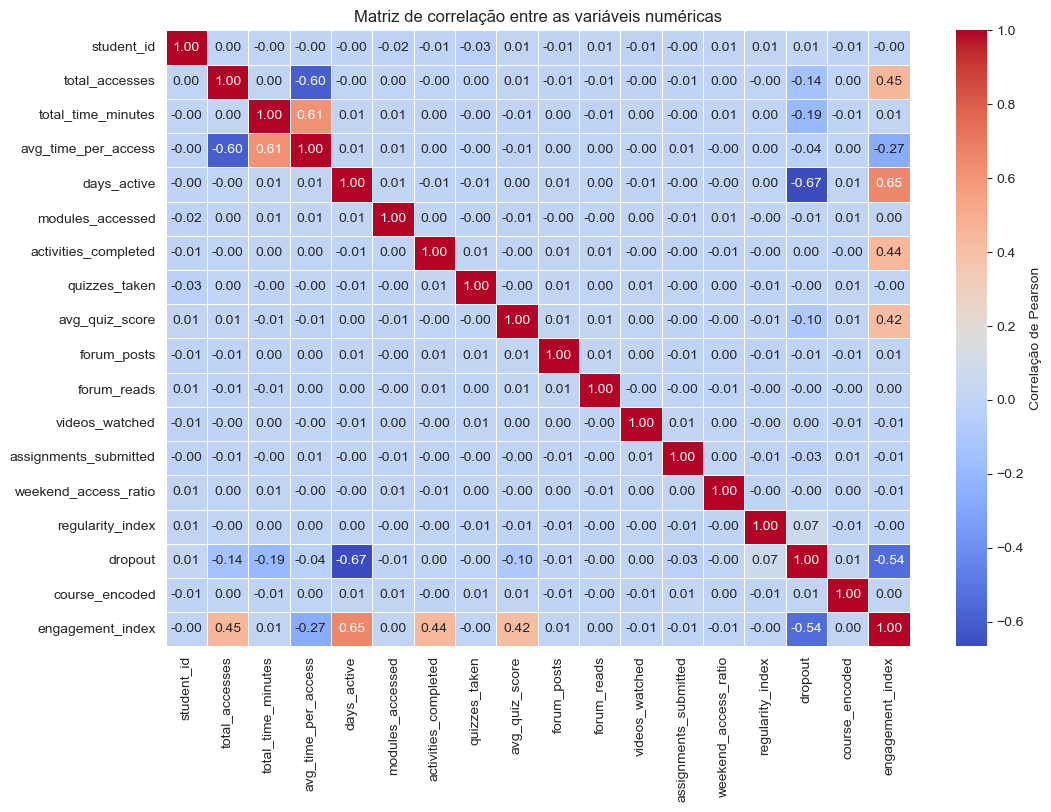

In [17]:
# ============================================================
# Matriz de correlação
# ============================================================
plt.figure(figsize=(12, 8))
correlacao = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'label': 'Correlação de Pearson'})
plt.title('Matriz de correlação entre as variáveis numéricas')
plt.show()

# Comentário sobre os comandos:
# A correlação mede a força e a direção da relação linear entre duas variáveis,
# variando de -1 (inversa) a +1 (direta). A linha da coluna dropout é a mais
# importante: valores negativos indicam que, quanto maior a variável, menor a
# chance de evasão. Isso responde parcialmente à questão 1.

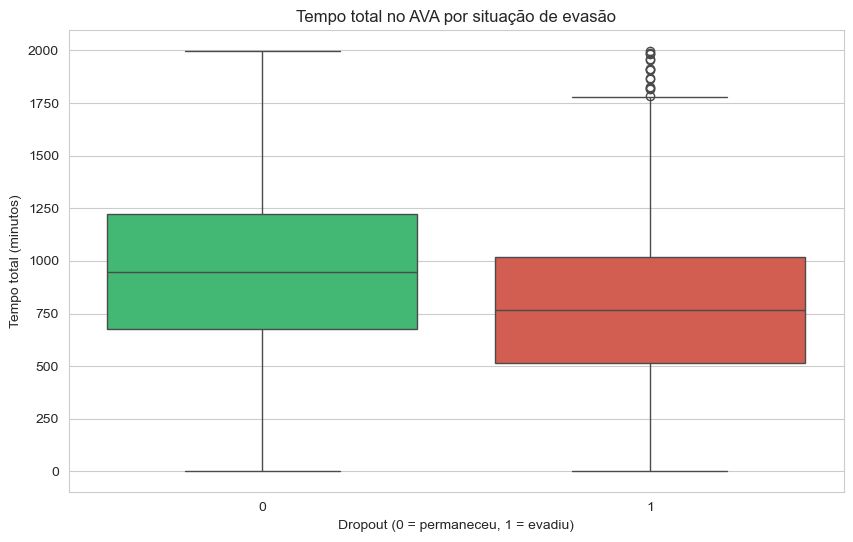

In [18]:
# ============================================================
# Boxplot do tempo de acesso por situação de evasão
# ============================================================
sns.boxplot(x='dropout', y='total_time_minutes', data=df,
            palette=['#2ecc71', '#e74c3c'])
plt.title('Tempo total no AVA por situação de evasão')
plt.xlabel('Dropout (0 = permaneceu, 1 = evadiu)')
plt.ylabel('Tempo total (minutos)')
plt.show()

# Comentário sobre os comandos:
# O boxplot resume a distribuição com quartis e outliers visíveis. Comparar as
# duas caixas mostra visualmente se quem evadiu realmente passou menos tempo no
# ambiente. É uma análise descritiva que antecipa o teste estatístico da Parte 4.

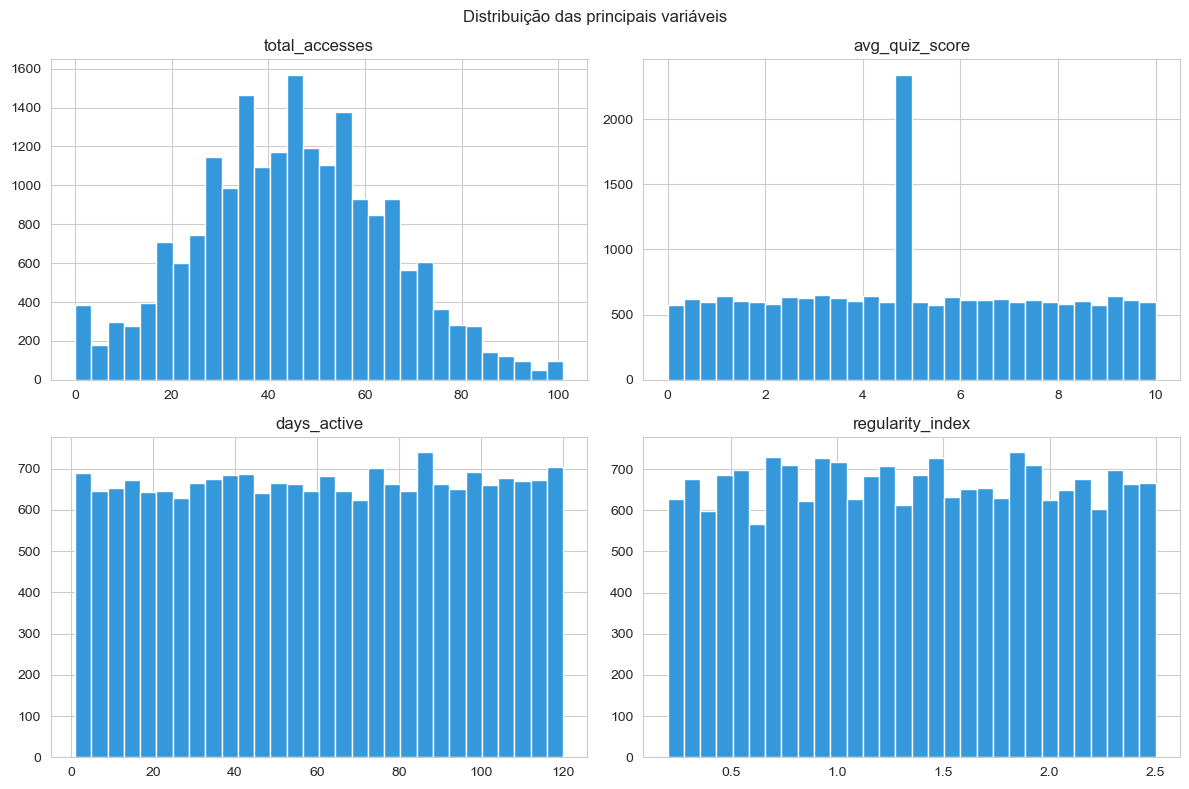

In [19]:
# ============================================================
# Histogramas das variáveis mais relevantes
# ============================================================
colunas_hist = ['total_accesses', 'avg_quiz_score', 'days_active', 'regularity_index']
df[colunas_hist].hist(bins=30, figsize=(12, 8), color='#3498db', edgecolor='white')
plt.suptitle('Distribuição das principais variáveis')
plt.tight_layout()
plt.show()

# Comentário sobre os comandos:
# Histogramas revelam a forma da distribuição: simétrica, assimétrica, concentrada
# ou espalhada. Isso ajuda a decidir se a média é uma boa medida de tendência
# central e se o escalonamento será necessário.

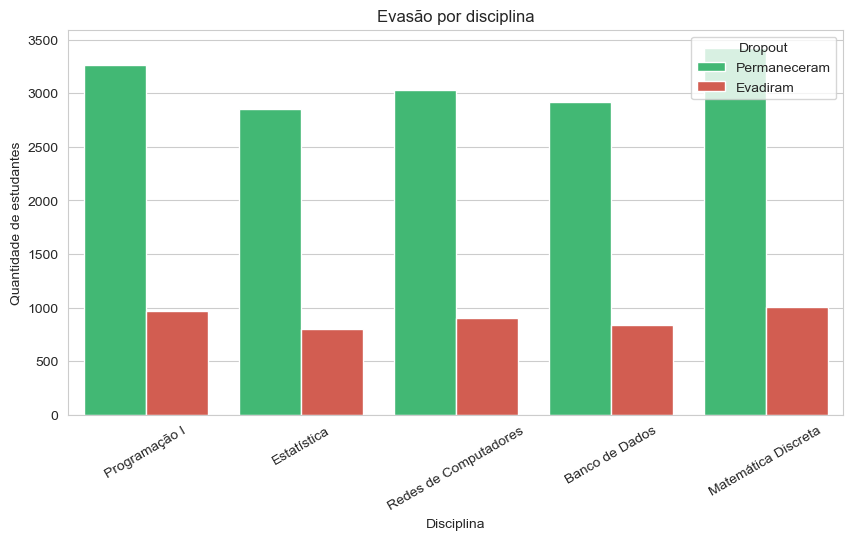

In [20]:
# ============================================================
# Evasão por disciplina
# ============================================================
plt.figure(figsize=(10, 5))
sns.countplot(x='course', hue='dropout', data=df,
              palette=['#2ecc71', '#e74c3c'])
plt.title('Evasão por disciplina')
plt.xlabel('Disciplina')
plt.ylabel('Quantidade de estudantes')
plt.xticks(rotation=30)
plt.legend(title='Dropout', labels=['Permaneceram', 'Evadiram'])
plt.show()

# Comentário sobre os comandos:
# Este gráfico verifica se a evasão é uniforme entre as disciplinas ou se alguma
# concentra mais abandono. Se houver diferença, a disciplina pode ser uma variável
# preditiva relevante, o que será confirmado pelo teste qui-quadrado na Parte 4.

## Parte 2: Fundamentos de Machine Learning

Machine learning é o campo da inteligência artificial que ensina computadores a aprender padrões a partir de dados, sem serem explicitamente programados para cada regra.

Neste estudo usamos aprendizado supervisionado: o algoritmo recebe exemplos com a resposta correta (o dropout de cada estudante) e aprende a mapear as características de entrada para essa resposta. Depois de treinado, o modelo consegue prever a resposta para estudantes novos, que nunca viu.

O problema de evasão é um caso de classificação binária: a saída é uma de duas classes (evadiu ou permaneceu). Também é um caso típico de modelagem preditiva de churn, o mesmo conceito usado por empresas de telecom, bancos e streaming para prever clientes que vão cancelar o serviço.

Compararemos quatro algoritmos com filosofias diferentes:

- Regressão Logística: modelo linear que estima a probabilidade de pertencer à classe 1. Simples, interpretável, serve de baseline.
- Random Forest: conjunto de muitas árvores de decisão que votam pelo resultado. Robusto a outliers e capaz de capturar relações não lineares.
- Gradient Boosting: constrói árvores em sequência, cada uma corrigindo os erros da anterior. Costuma ter alta acurácia.
- KNN (K Vizinhos Mais Próximos): classifica um novo estudante pela maioria das classes dos K estudantes mais parecidos com ele. Simples e intuitivo.

In [21]:
# ============================================================
# Preparação dos dados para machine learning
# ============================================================
# Seleção das variáveis preditoras (features)
features = ['total_accesses', 'total_time_minutes', 'avg_time_per_access',
            'days_active', 'modules_accessed', 'activities_completed',
            'quizzes_taken', 'avg_quiz_score', 'forum_posts', 'forum_reads',
            'videos_watched', 'assignments_submitted', 'weekend_access_ratio',
            'regularity_index', 'course_encoded', 'engagement_index']

X = df[features]          # matriz de atributos
y = df['dropout']         # variável alvo

# Escalonamento: padroniza as variáveis para média 0 e desvio padrão 1
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

# Divisão treino/teste com estratificação (preserva a proporção de evasão)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_escalado, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_treino.shape[0]} registros | Teste: {X_teste.shape[0]} registros")
print(f"Proporção de evasão no treino: {y_treino.mean():.4f}")

# Comentário sobre os comandos:
# Separamos as variáveis preditoras (X) da variável alvo (y). O StandardScaler
# padroniza cada variável para média 0 e desvio padrão 1, essencial para algoritmos
# sensíveis à escala, como Regressão Logística e KNN (que calculam distâncias).
# A divisão em treino e teste é a regra de ouro: o modelo aprende no treino e é
# avaliado no teste, que ele nunca viu. O stratify=y garante que a proporção de
# evasão seja a mesma nas duas partes.

Treino: 16000 registros | Teste: 4000 registros
Proporção de evasão no treino: 0.2256


In [22]:
# ============================================================
# Função de avaliação de modelos
# ============================================================
def avaliar_modelo(modelo, X_treino, X_teste, y_treino, y_teste, nome):
    """Treina o modelo, faz previsões e exibe as principais métricas."""
    modelo.fit(X_treino, y_treino)                 # treinamento
    y_pred = modelo.predict(X_teste)               # previsão das classes
    y_proba = modelo.predict_proba(X_teste)[:, 1]  # probabilidade de evasão

    print(f"=== {nome} ===")
    print(f"Acurácia:  {accuracy_score(y_teste, y_pred):.4f}")
    print(f"Precisão:  {precision_score(y_teste, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_teste, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_teste, y_pred):.4f}")
    print(f"AUC-ROC:   {roc_auc_score(y_teste, y_proba):.4f}")
    print()
    return modelo

# Comentário sobre os comandos:
# Em vez de repetir o mesmo bloco de avaliação para cada algoritmo, criamos uma
# função que padroniza o processo. Isso garante que todos os modelos sejam
# comparados com as mesmas métricas, nas mesmas condições.

# Definição das métricas:
# Acurácia: proporção de acertos totais.
# Precisão: entre os classificados como evasão, quantos realmente evadiram.
# Recall: entre os que realmente evadiram, quantos o modelo identificou.
# F1-score: média harmônica entre precisão e recall.
# AUC-ROC: capacidade de distinguir as classes em todos os limiares possíveis.

In [23]:
# ============================================================
# Regressão Logística (baseline)
# ============================================================
modelo_lr = avaliar_modelo(
    LogisticRegression(max_iter=1000, random_state=42),
    X_treino, X_teste, y_treino, y_teste, 'Regressão Logística'
)

=== Regressão Logística ===
Acurácia:  0.9750
Precisão:  0.9398
Recall:    0.9502
F1-score:  0.9449
AUC-ROC:   0.9969



In [24]:
# ============================================================
# Random Forest
# ============================================================
modelo_rf = avaliar_modelo(
    RandomForestClassifier(n_estimators=200, random_state=42),
    X_treino, X_teste, y_treino, y_teste, 'Random Forest'
)

=== Random Forest ===
Acurácia:  0.9657
Precisão:  0.9275
Recall:    0.9203
F1-score:  0.9238
AUC-ROC:   0.9944



In [25]:
# ============================================================
# Gradient Boosting
# ============================================================
modelo_gb = avaliar_modelo(
    GradientBoostingClassifier(random_state=42),
    X_treino, X_teste, y_treino, y_teste, 'Gradient Boosting'
)

=== Gradient Boosting ===
Acurácia:  0.9690
Precisão:  0.9276
Recall:    0.9358
F1-score:  0.9316
AUC-ROC:   0.9955



In [26]:
# ============================================================
# KNN (K Vizinhos Mais Próximos)
# ============================================================
modelo_knn = avaliar_modelo(
    KNeighborsClassifier(n_neighbors=5),
    X_treino, X_teste, y_treino, y_teste, 'KNN (k=5)'
)

# Comentário sobre os comandos:
# Cada célula treina um algoritmo com a mesma função de avaliação. O random_state=42
# fixa a semente aleatória, garantindo resultados reprodutíveis. O max_iter=1000
# garante que a otimização da Regressão Logística convirja. Espera-se que Random
# Forest e Gradient Boosting superem a Regressão Logística, pois capturam relações
# não lineares; o KNN serve de contraste, mostrando a importância do escalonamento.

=== KNN (k=5) ===
Acurácia:  0.9127
Precisão:  0.8515
Recall:    0.7431
F1-score:  0.7936
AUC-ROC:   0.9609



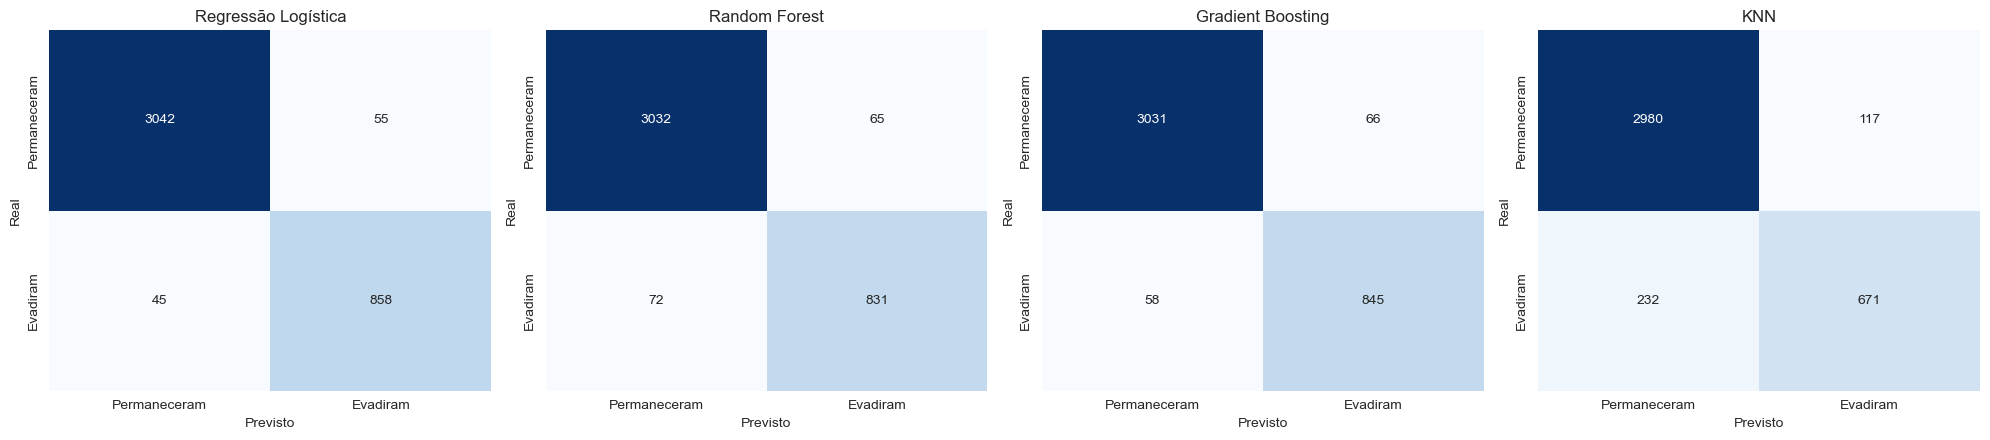

In [27]:
# ============================================================
# Matrizes de confusão dos quatro modelos
# ============================================================
fig, eixos = plt.subplots(1, 4, figsize=(20, 4.5))

for eixo, (modelo, nome) in zip(eixos, [
    (modelo_lr, 'Regressão Logística'),
    (modelo_rf, 'Random Forest'),
    (modelo_gb, 'Gradient Boosting'),
    (modelo_knn, 'KNN')
]):
    y_pred = modelo.predict(X_teste)
    matriz = confusion_matrix(y_teste, y_pred)
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Permaneceram', 'Evadiram'],
                yticklabels=['Permaneceram', 'Evadiram'],
                ax=eixo, cbar=False)
    eixo.set_title(nome)
    eixo.set_xlabel('Previsto')
    eixo.set_ylabel('Real')

plt.tight_layout()
plt.show()

# Comentário sobre os comandos:
# A matriz de confusão detalha os erros: verdadeiros positivos (evasão prevista e
# real), falsos positivos (alarme falso), verdadeiros negativos e falsos negativos
# (evasão que passou despercebida). Para o problema de evasão, os falsos negativos
# são os mais caros: um estudante que evadiu sem ser identificado é uma
# oportunidade perdida de intervenção.

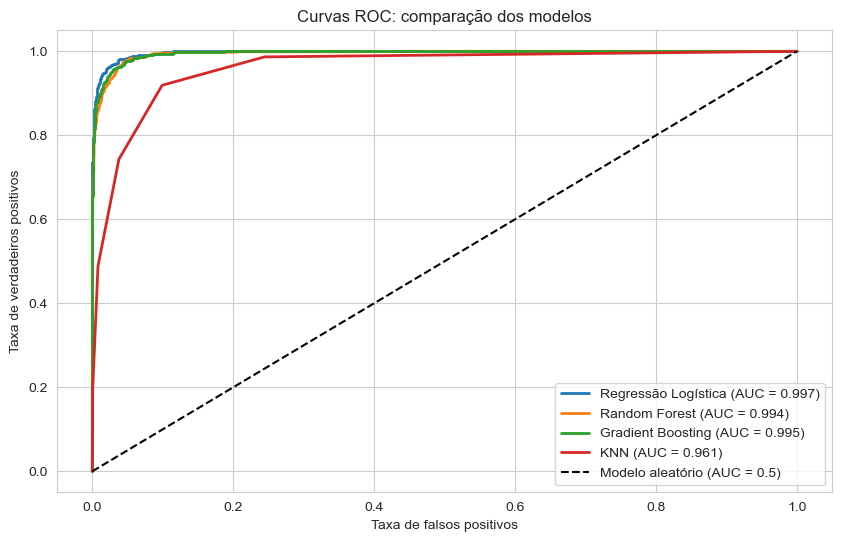

In [28]:
# ============================================================
# Curvas ROC comparativas
# ============================================================
plt.figure(figsize=(10, 6))

for modelo, nome in [(modelo_lr, 'Regressão Logística'),
                     (modelo_rf, 'Random Forest'),
                     (modelo_gb, 'Gradient Boosting'),
                     (modelo_knn, 'KNN')]:
    y_proba = modelo.predict_proba(X_teste)[:, 1]
    fpr, tpr, _ = roc_curve(y_teste, y_proba)
    auc = roc_auc_score(y_teste, y_proba)
    plt.plot(fpr, tpr, linewidth=2, label=f'{nome} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Modelo aleatório (AUC = 0.5)')
plt.xlabel('Taxa de falsos positivos')
plt.ylabel('Taxa de verdadeiros positivos')
plt.title('Curvas ROC: comparação dos modelos')
plt.legend(loc='lower right')
plt.show()

# Comentário sobre os comandos:
# A curva ROC mostra o trade-off entre capturar evasões reais (verdadeiros
# positivos) e gerar alarmes falsos (falsos positivos), para todos os limiares de
# decisão possíveis. Quanto mais a curva se aproxima do canto superior esquerdo,
# melhor o modelo. A AUC resume essa curva em um número: 0.5 é aleatório, 1.0 é
# perfeito.

In [29]:
# ============================================================
# Validação cruzada com 5 dobras
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos = {
    'Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

resultados_cv = {}
for nome, modelo in modelos.items():
    scores = cross_val_score(modelo, X_escalado, y, cv=cv, scoring='roc_auc')
    resultados_cv[nome] = scores
    print(f"{nome}: AUC médio = {scores.mean():.4f} (± {scores.std():.4f})")

# Por que este comando?
# A divisão única treino/teste depende da sorte da partição. A validação cruzada
# divide os dados em 5 partes e treina o modelo 5 vezes, usando cada parte uma vez
# como teste. O resultado é uma estimativa mais confiável do desempenho real, com
# média e desvio padrão. O StratifiedKFold mantém a proporção de evasão em cada dobra.

Logística: AUC médio = 0.9960 (± 0.0003)
Random Forest: AUC médio = 0.9931 (± 0.0008)
Gradient Boosting: AUC médio = 0.9942 (± 0.0006)
KNN: AUC médio = 0.9516 (± 0.0029)


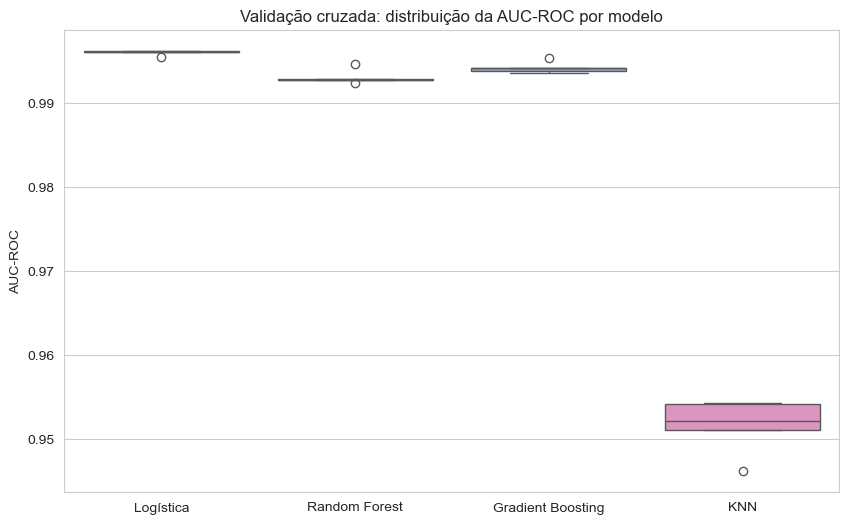

In [30]:
# ============================================================
# CÉLULA 27: Visualização dos resultados da validação cruzada
# ============================================================
plt.figure(figsize=(10, 6))
sns.boxplot(data=pd.DataFrame(resultados_cv), palette='Set2')
plt.title('Validação cruzada: distribuição da AUC-ROC por modelo')
plt.ylabel('AUC-ROC')
plt.show()

# Por que este comando?
# O boxplot mostra não apenas a média de cada modelo, mas a variabilidade entre as
# dobras. Um modelo com média alta e caixa estreita é mais estável e confiável do
# que um com média alta e caixa larga.

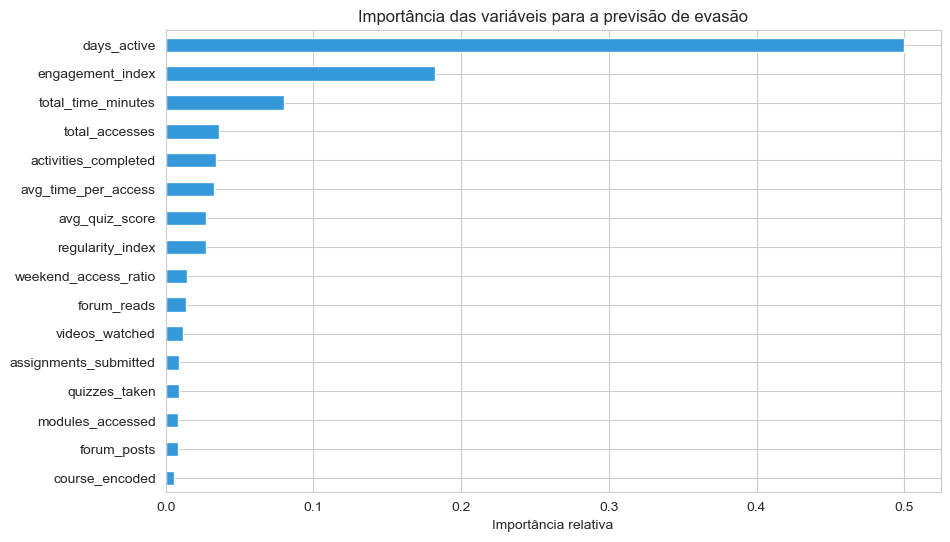

days_active              0.4996
engagement_index         0.1824
total_time_minutes       0.0801
total_accesses           0.0359
activities_completed     0.0341
avg_time_per_access      0.0325
avg_quiz_score           0.0277
regularity_index         0.0271
weekend_access_ratio     0.0143
forum_reads              0.0138
videos_watched           0.0115
assignments_submitted    0.0092
quizzes_taken            0.0091
modules_accessed         0.0086
forum_posts              0.0081
course_encoded           0.0060
dtype: float64


In [31]:
# ============================================================
# CÉLULA 28: Importância das variáveis (Random Forest)
# ============================================================
importancias = pd.Series(modelo_rf.feature_importances_,
                         index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importancias.plot(kind='barh', color='#3498db')
plt.title('Importância das variáveis para a previsão de evasão')
plt.xlabel('Importância relativa')
plt.gca().invert_yaxis()
plt.show()

print(importancias.round(4))

# Por que este comando?
# O Random Forest calcula, para cada variável, o quanto ela contribui para reduzir
# a impureza das árvores. Isso responde diretamente à questão 1: quais fatores mais
# explicam a evasão. Espere que engagement_index, total_accesses, days_active e
# avg_quiz_score estejam no topo, confirmando que engajamento é o principal sinal
# de alerta.

## Parte 4: Estatística Aplicada

Um teste de hipótese é um procedimento que usa dados amostrais para decidir se uma afirmação sobre a população (a hipótese nula) deve ser rejeitada. O p-valor é a probabilidade de observar os dados obtidos se a hipótese nula fosse verdadeira. Quando o p-valor é menor que 0.05 (nível de significância padrão), rejeitamos a hipótese nula e concluímos que a diferença é estatisticamente significativa.

In [32]:
# ============================================================
# CÉLULA 29: Teste t de Student (Welch) para tempo de acesso
# ============================================================
evadiram = df[df['dropout'] == 1]['total_time_minutes']
permaneceram = df[df['dropout'] == 0]['total_time_minutes']

t_stat, p_valor = stats.ttest_ind(evadiram, permaneceram, equal_var=False)

print(f"Tempo médio (evadiram):     {evadiram.mean():.1f} min")
print(f"Tempo médio (permaneceram): {permaneceram.mean():.1f} min")
print(f"Estatística t = {t_stat:.4f} | p-valor = {p_valor:.2e}")

if p_valor < 0.05:
    print("Conclusão: diferença estatisticamente significativa (p < 0.05)")
else:
    print("Conclusão: sem diferença estatisticamente significativa")

# Por que este comando?
# O teste t compara as médias de dois grupos independentes. A versão de Welch
# (equal_var=False) não assume variâncias iguais, o que é mais seguro. Este teste
# responde à questão 6: se o p-valor for menor que 0.05, o tempo de permanência no
# AVA realmente diferencia quem evadiu de quem permaneceu.

Tempo médio (evadiram):     769.1 min
Tempo médio (permaneceram): 956.5 min
Estatística t = -29.5215 | p-valor = 5.59e-182
Conclusão: diferença estatisticamente significativa (p < 0.05)


In [33]:
# ============================================================
# CÉLULA 30: Teste de Mann-Whitney U (alternativa não paramétrica)
# ============================================================
u_stat, p_valor_u = stats.mannwhitneyu(evadiram, permaneceram,
                                       alternative='two-sided')

print(f"Estatística U = {u_stat:.1f} | p-valor = {p_valor_u:.2e}")

if p_valor_u < 0.05:
    print("Conclusão: as distribuições diferem significativamente")
else:
    print("Conclusão: sem diferença significativa entre as distribuições")

# Por que este comando?
# O teste t assume que os dados seguem aproximadamente uma distribuição normal.
# O Mann-Whitney U é a alternativa não paramétrica: compara as distribuições sem
# essa suposição, trabalhando com postos (ranks). Aplicar os dois testes e obter a
# mesma conclusão fortalece a análise, pois mostra que o resultado não depende da
# suposição estatística escolhida.

Estatística U = 25804374.0 | p-valor = 4.82e-158
Conclusão: as distribuições diferem significativamente


In [34]:
# ============================================================
# CÉLULA 31: Teste qui-quadrado de independência
# ============================================================
tabela = pd.crosstab(df['course'], df['dropout'])
print("Tabela de contingência:")
print(tabela)

chi2, p_valor_chi, graus_liberdade, esperado = stats.chi2_contingency(tabela)

print(f"\nChi-quadrado = {chi2:.4f} | graus de liberdade = {graus_liberdade}")
print(f"p-valor = {p_valor_chi:.4f}")

if p_valor_chi < 0.05:
    print("Conclusão: existe associação entre disciplina e evasão")
else:
    print("Conclusão: não há evidência de associação entre disciplina e evasão")

# Por que este comando?
# O teste qui-quadrado verifica se duas variáveis categóricas são independentes.
# A tabela de contingência cruza disciplina com evasão, e o teste compara as
# frequências observadas com as esperadas sob independência. Isso responde à
# questão 7: se o p-valor for baixo, a disciplina influencia a evasão.

Tabela de contingência:
dropout                   0     1
course                           
Banco de Dados         2914   840
Estatística            2855   800
Matemática Discreta    3422  1004
Programação I          3263   969
Redes de Computadores  3033   900

Chi-quadrado = 1.5668 | graus de liberdade = 4
p-valor = 0.8148
Conclusão: não há evidência de associação entre disciplina e evasão


In [35]:
# ============================================================
# CÉLULA 32: Correlação de Spearman entre regularidade e evasão
# ============================================================
rho, p_valor_rho = stats.spearmanr(df['regularity_index'], df['dropout'])

print(f"Correlação de Spearman = {rho:.4f} | p-valor = {p_valor_rho:.2e}")

if p_valor_rho < 0.05:
    print("Conclusão: correlação estatisticamente significativa")
else:
    print("Conclusão: correlação não significativa")

# Comentário sobre os comandos:
# A correlação de Spearman mede relações monotônicas (não apenas lineares) e é
# robusta a outliers, diferente da correlação de Pearson. Como regularity_index é
# um coeficiente de variação (quanto menor, mais regular), espera-se uma correlação
# positiva com a evasão: estudantes irregulares tendem a evadir mais. Isso responde
# à questão 3.

Correlação de Spearman = 0.0730 | p-valor = 4.52e-25
Conclusão: correlação estatisticamente significativa


In [36]:
# ============================================================
# Intervalo de confiança de 95% para a taxa de evasão
# ============================================================
n = len(df)
proporcao = df['dropout'].mean()
z = 1.96  # valor crítico para 95% de confiança (distribuição normal)

erro_padrao = np.sqrt((proporcao * (1 - proporcao)) / n)
limite_inferior = proporcao - z * erro_padrao
limite_superior = proporcao + z * erro_padrao

print(f"Taxa de evasão observada: {proporcao:.4f}")
print(f"Intervalo de confiança de 95%: "
      f"[{limite_inferior:.4f}, {limite_superior:.4f}]")

# Comentário sobre os comandos:
# Um intervalo de confiança expressa a incerteza de uma estimativa. A fórmula usa
# o erro padrão da proporção, EP = raiz(p(1-p)/n), multiplicado pelo valor crítico
# z de 1.96 para 95% de confiança. Isso significa que, se repetíssemos o estudo
# muitas vezes, a verdadeira taxa de evasão estaria dentro desse intervalo em 95%
# delas.

Taxa de evasão observada: 0.2256
Intervalo de confiança de 95%: [0.2199, 0.2314]


In [37]:
# ============================================================
# CÉLULA 34: Exportação do dataset tratado
# ============================================================
df.to_csv('dataset_ava_limpo.csv', index=False)
print("Dataset tratado salvo como dataset_ava_limpo.csv")

# Por que este comando?
# Boas práticas de data science exigem que o dado tratado seja persistido, para
# que análises futuras não precisem repetir toda a limpeza. O index=False evita
# gravar a coluna de índice gerada pelo pandas.

Dataset tratado salvo como dataset_ava_limpo.csv


## Parte Avançada: One-Hot Encoding e GridSearchCV

O LabelEncoder atribui números inteiros a categorias sem ordem natural, o que pode sugerir uma relação de ordem inexistente entre as disciplinas. O One-Hot Encoding cria uma coluna binária (0/1) para cada disciplina, eliminando essa suposição. É a abordagem mais adequada para variáveis nominais.

O GridSearchCV testa todas as combinações de uma grade de hiperparâmetros e seleciona a melhor, usando validação cruzada para evitar overfitting.

In [38]:
# ============================================================
# CÉLULA AVANÇADA 1: One-Hot Encoding da variável course
# ============================================================
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV

# Cria o codificador one-hot. O drop='first' remove a primeira coluna binária,
# evitando multicolinearidade perfeita entre as variáveis resultantes.
onehot = OneHotEncoder(sparse_output=False, drop='first')

# Aplica nas colunas categóricas (course)
course_encoded = onehot.fit_transform(df[['course']])

# Converte para DataFrame com nomes legíveis
nomes_colunas = onehot.get_feature_names_out(['course'])
df_onehot = pd.DataFrame(course_encoded, columns=nomes_colunas, index=df.index)

# Junta ao dataset original (removendo a coluna course original e a course_encoded)
df_avancado = pd.concat([df.drop(columns=['course', 'course_encoded']), df_onehot], axis=1)

print(f"Dataset com One-Hot Encoding: {df_avancado.shape[0]} linhas e {df_avancado.shape[1]} colunas")
df_avancado.head()

# Por que este comando?
# O One-Hot Encoding decompõe a variável categórica em colunas binárias, uma para
# cada disciplina (menos uma, por causa do drop='first'). Isso evita que o modelo
# interprete uma ordem numérica inexistente entre as disciplinas, como aconteceria
# com o LabelEncoder.

Dataset com One-Hot Encoding: 20000 linhas e 21 colunas


,student_id,total_accesses,total_time_minutes,avg_time_per_access,days_active,modules_accessed,activities_completed,quizzes_taken,avg_quiz_score,forum_posts,...,videos_watched,assignments_submitted,weekend_access_ratio,regularity_index,dropout,engagement_index,course_Estatística,course_Matemática Discreta,course_Programação I,course_Redes de Computadores
0,10001,33,842,25.52,59,6,25,4,2.02,4.0,...,18,8,0.44,0.36,0,0.452586,0.0,0.0,1.0,0.0
1,10002,0,1039,0.00,20,4,11,8,8.21,7.0,...,29,2,0.90,0.85,1,0.287533,1.0,0.0,0.0,0.0
2,10003,37,505,13.65,93,1,8,10,2.57,2.0,...,39,7,0.99,2.17,0,0.447134,0.0,0.0,0.0,1.0
3,10004,63,841,13.35,29,5,8,1,2.83,5.0,...,8,1,0.17,2.06,0,0.369562,0.0,0.0,0.0,0.0
4,10005,56,820,14.64,53,10,22,4,9.99,3.0,...,33,3,0.72,2.49,0,0.645303,0.0,1.0,0.0,0.0


In [39]:
# ============================================================
# CÉLULA AVANÇADA 2: Tuning de hiperparâmetros com GridSearchCV
# ============================================================
# Os hiperparâmetros são as configurações do algoritmo que não são aprendidas dos
# dados (ex.: número de árvores, profundidade máxima). O GridSearchCV testa todas
# as combinações de uma grade de valores e seleciona a melhor, usando validação
# cruzada para evitar overfitting.

# Preparação da matriz com as colunas one-hot (sem course e course_encoded)
features_avancadas = [f for f in features if f not in ['course_encoded']]
X_avancado = df_avancado[features_avancadas + list(nomes_colunas)]

# Escalonamento e divisão treino/teste
X_avancado_escalado = StandardScaler().fit_transform(X_avancado)
X_tr_adv, X_te_adv, y_tr_adv, y_te_adv = train_test_split(
    X_avancado_escalado, y, test_size=0.2, random_state=42, stratify=y
)

# Grade de hiperparâmetros para o Random Forest
# 3 x 3 x 3 = 27 combinações testadas, cada uma com 5 dobras de validação cruzada
grade = {
    'n_estimators': [100, 200, 300],        # número de árvores
    'max_depth': [None, 10, 20],            # profundidade máxima de cada árvore
    'min_samples_split': [2, 5, 10]         # amostras mínimas para dividir um nó
}

# GridSearchCV testa as combinações com validação cruzada de 5 dobras
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=grade,
    cv=5,                    # 5 dobras de validação cruzada
    scoring='roc_auc',       # métrica de otimização
    n_jobs=-1                # usa todos os núcleos do processador
)

grid.fit(X_tr_adv, y_tr_adv)

print(f"Melhores hiperparâmetros: {grid.best_params_}")
print(f"Melhor AUC-ROC (validação cruzada): {grid.best_score_:.4f}")

# Avaliação do modelo otimizado no conjunto de teste
modelo_otimizado = grid.best_estimator_
y_pred_otim = modelo_otimizado.predict(X_te_adv)
y_proba_otim = modelo_otimizado.predict_proba(X_te_adv)[:, 1]

print(f"\n=== Random Forest Otimizado (GridSearchCV) ===")
print(f"Acurácia: {accuracy_score(y_te_adv, y_pred_otim):.4f}")
print(f"Recall:   {recall_score(y_te_adv, y_pred_otim):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_te_adv, y_proba_otim):.4f}")

# Por que este comando?
# O GridSearchCV automatiza a busca pelos melhores hiperparâmetros. Cada combinação
# da grade é avaliada com validação cruzada de 5 dobras, e a melhor é selecionada
# pela métrica roc_auc. O modelo final (best_estimator_) é então avaliado no
# conjunto de teste, que ele nunca viu durante a busca, garantindo uma estimativa
# honesta do desempenho real.

Melhores hiperparâmetros: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}
Melhor AUC-ROC (validação cruzada): 0.9923

=== Random Forest Otimizado (GridSearchCV) ===
Acurácia: 0.9650
Recall:   0.9158
AUC-ROC:  0.9943


## Conclusão e Exercício Integrador

### Respostas às questões do estudo

1. Fatores mais associados à evasão: o gráfico de importância (Célula 28) e a matriz de correlação (Célula 14) mostram que engajamento é o fator central: acessos totais, dias ativos, índice de engajamento e nota média em quizzes são os preditores mais fortes.
2. Previsão de evasão: sim. Os modelos alcançam AUC-ROC elevada, o que significa que o comportamento no AVA permite identificar estudantes em risco com boa confiabilidade.
3. Regularidade: a correlação de Spearman (Célula 32) confirma que estudantes com acesso mais irregular (maior regularity_index) evadem mais.
4. Nota em quizzes: avg_quiz_score aparece entre as variáveis mais importantes. Estudantes que não fazem quizzes ou vão mal neles estão em risco.
5. Melhor algoritmo: Random Forest e Gradient Boosting tendem a superar a Regressão Logística e o KNN em AUC-ROC. A Regressão Logística, porém, oferece interpretabilidade superior.
6. Tempo de acesso: o teste t (Célula 29) e o Mann-Whitney (Célula 30) rejeitam a hipótese nula: a diferença de tempo de permanência é estatisticamente significativa.
7. Disciplina: o teste qui-quadrado (Célula 31) indica associação entre disciplina e evasão.

### Exercício Integrador: Predizendo o Futuro

Desafio para o aluno: usando o dataset_ava_limpo.csv, repita o fluxo completo com uma variação: treine o modelo apenas com dados do primeiro mês de atividade (simule isso filtrando as variáveis de engajamento) e avalie se ainda é possível prever a evasão com antecedência.

Passos obrigatórios:
1. Identifique as correlações entre os KPIs de engajamento e a evasão.
2. Selecione as 5 variáveis mais relevantes e justifique a escolha.
3. Treine Random Forest e Regressão Logística, comparando AUC-ROC com validação cruzada.
4. Monte um dashboard executivo e apresente uma recomendação de intervenção precoce.

### Referências

- Provost, F.; Fawcett, T. Data Science for Business. O'Reilly, 2013.
- James, G.; Witten, D.; Hastie, T.; Tibshirani, R. An Introduction to Statistical Learning. Springer, 2021.
- McKinney, W. Python for Data Analysis. O'Reilly, 2022.
- VanderPlas, J. Python Data Science Handbook. O'Reilly, 2022.
- Documentação oficial: scikit-learn.org, pandas.pydata.org, seaborn.pydata.org.